In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA


In [2]:
df=pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.shape

(6607, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
df.isnull().mean()

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               0.011806
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      0.013622
Distance_from_Home            0.010141
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64

In [6]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [7]:
df=df[df["Exam_Score"]<100]

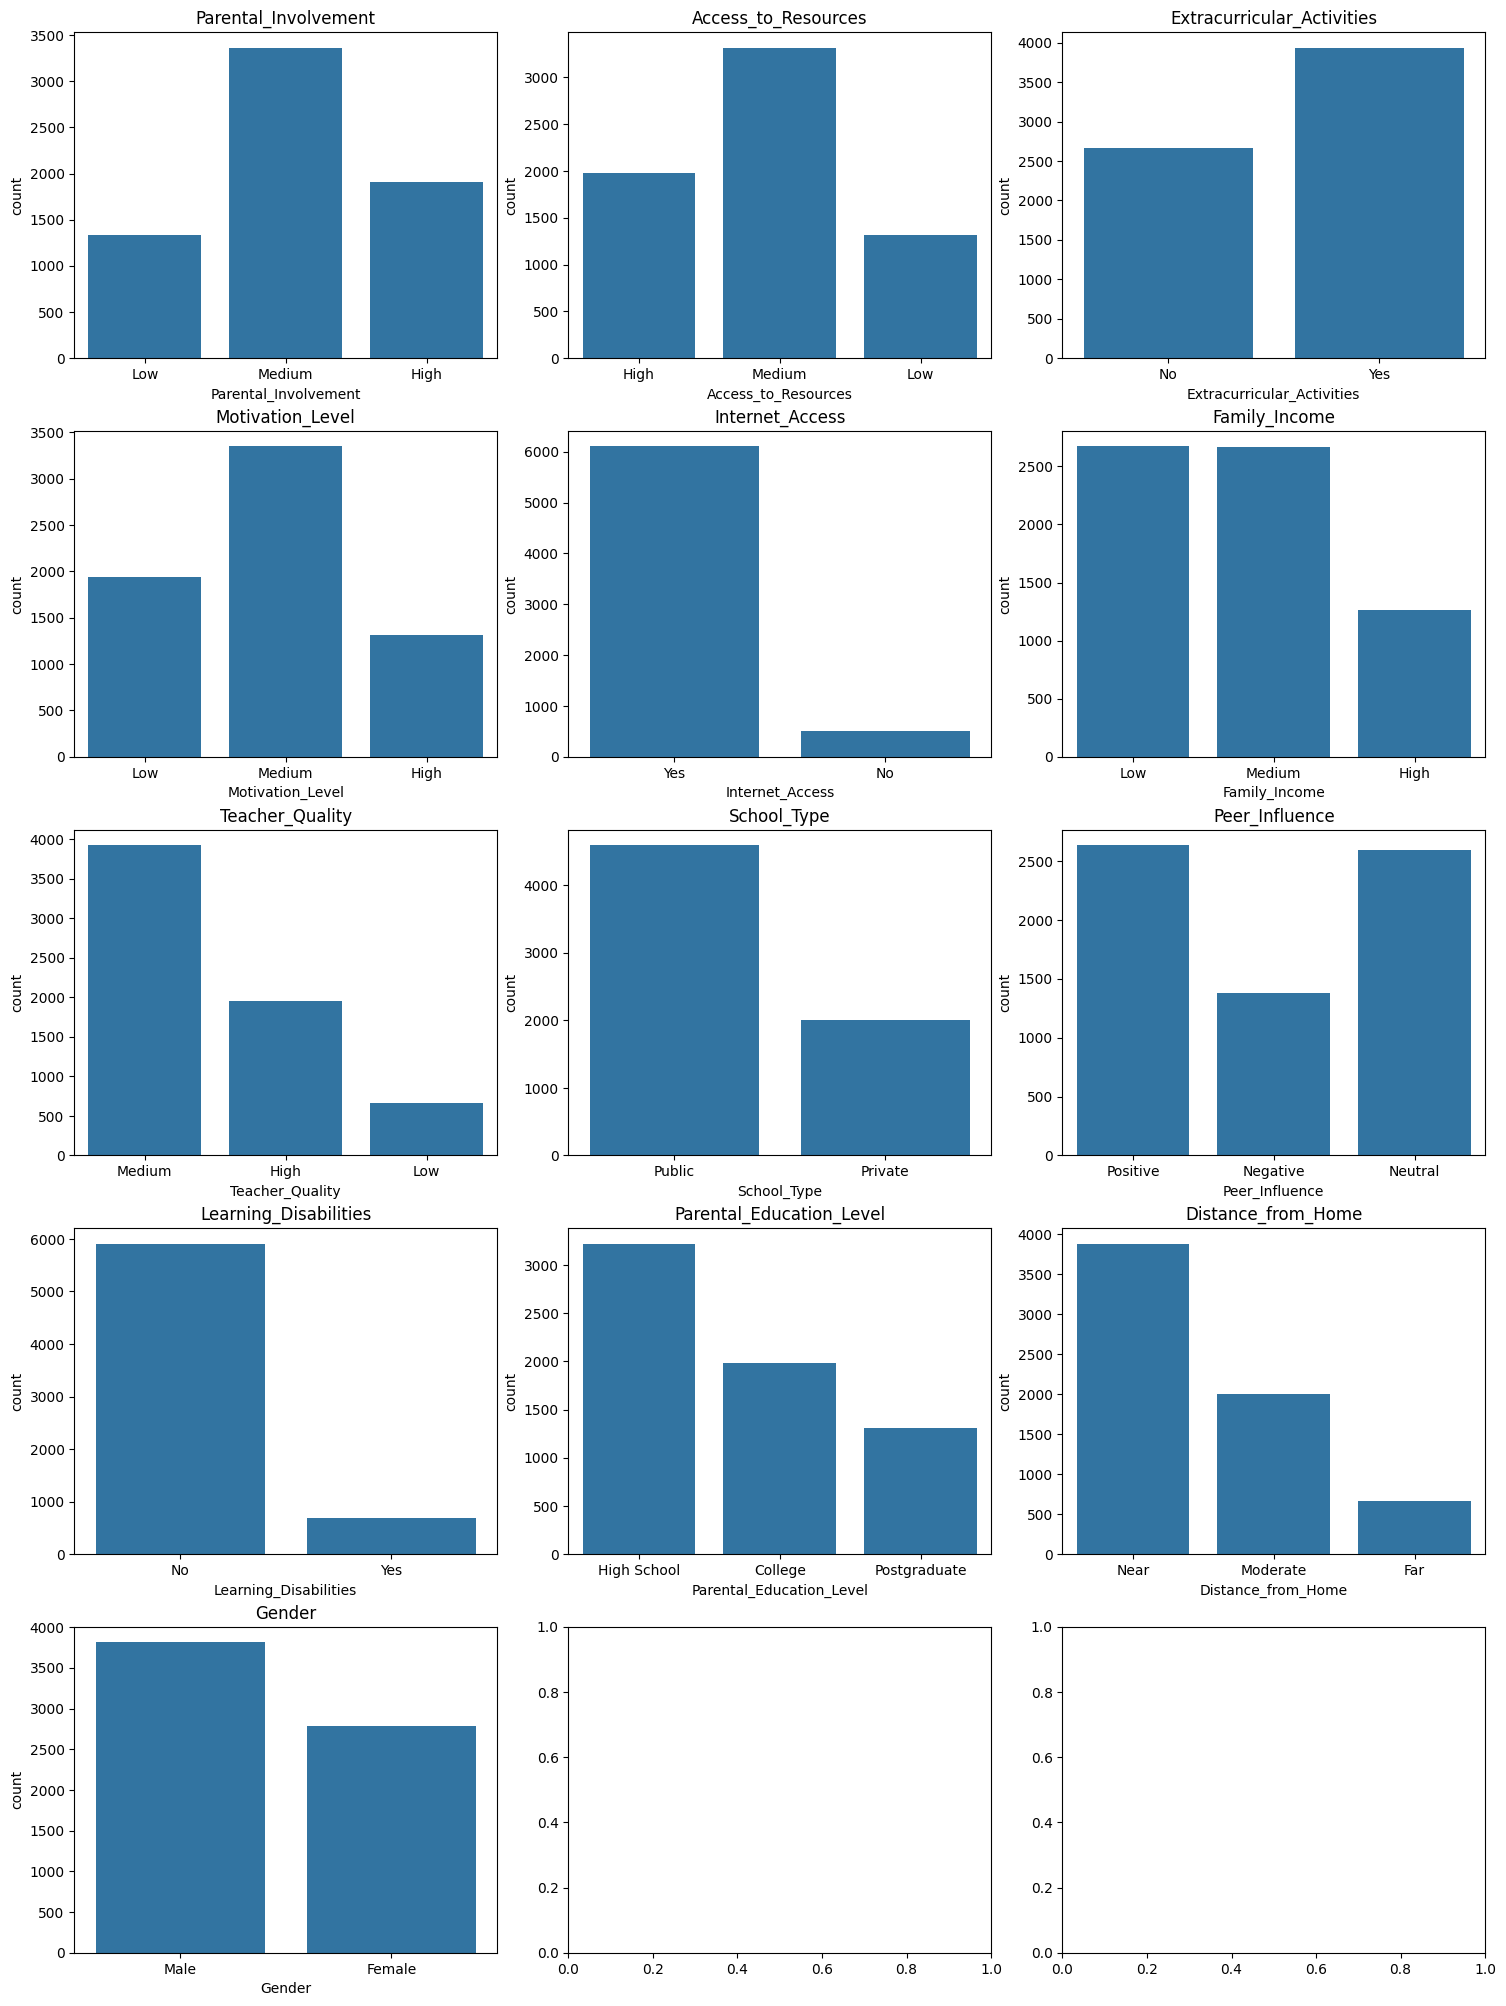

In [8]:

cat_cols = df.select_dtypes(include='object').columns


fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout(pad=0.5)

plt.show()



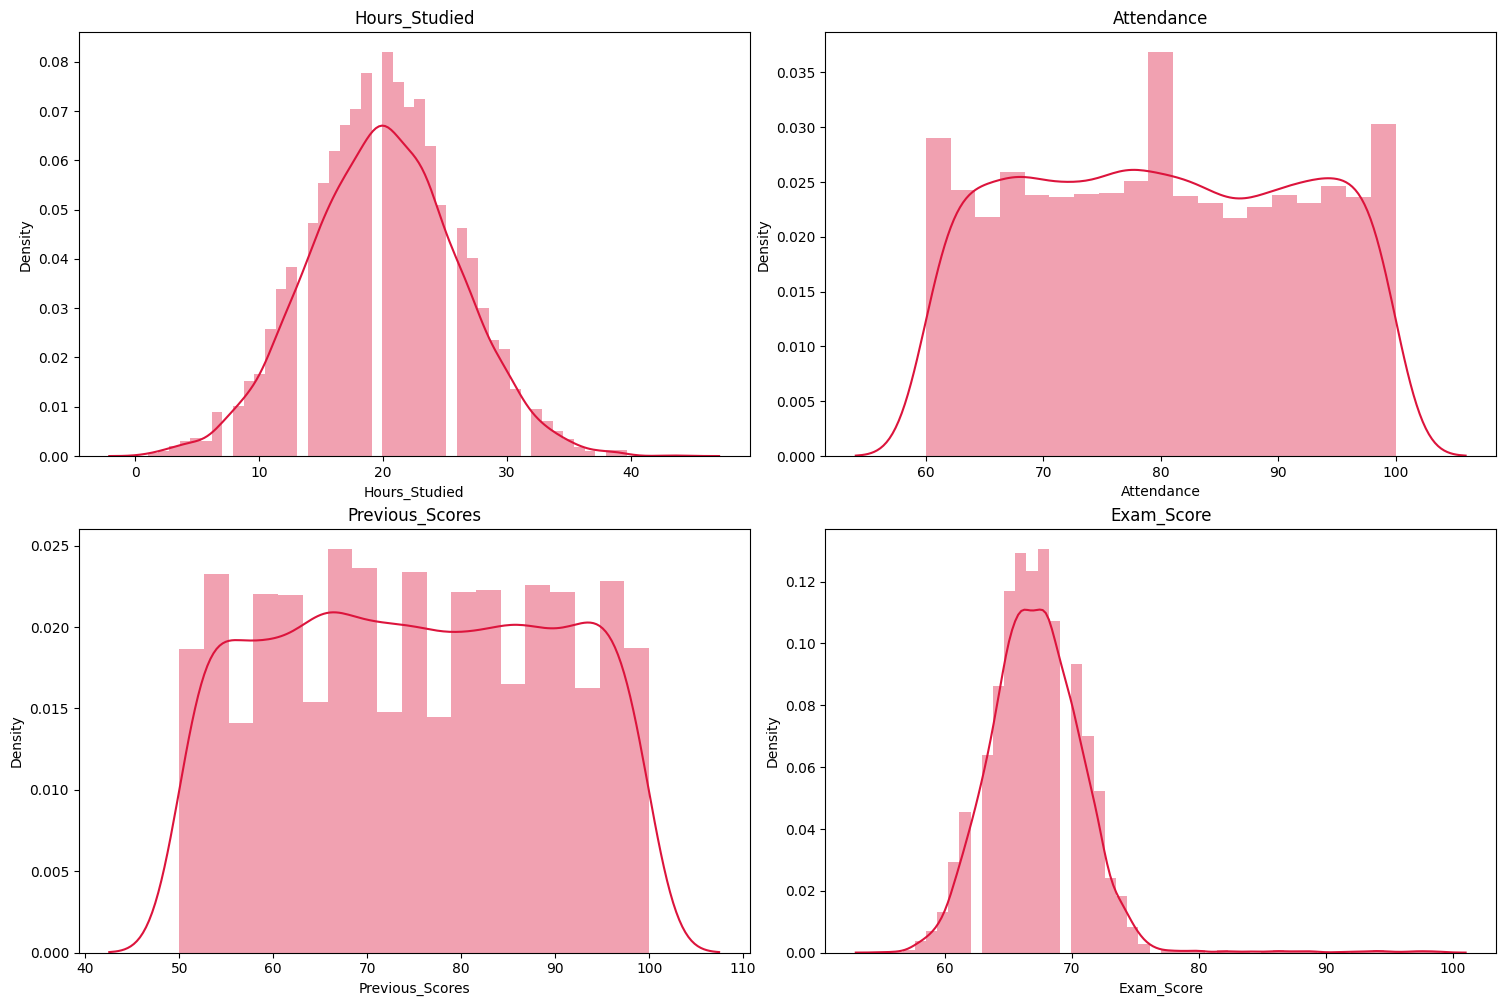

In [9]:
con_col=["Hours_Studied","Attendance","Previous_Scores","Exam_Score"]

fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(15,10))
axes=axes.flatten()

for i,col in enumerate(con_col):
    sns.distplot(df[col],ax=axes[i],kde=True,color="crimson")
    axes[i].set_title(col)


plt.tight_layout(pad=0.5)

plt.show()


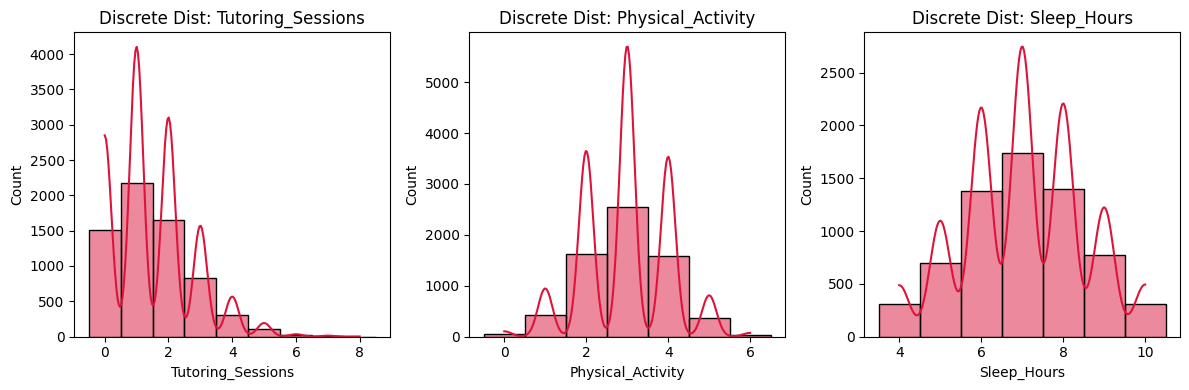

In [10]:
discrete_cols = ['Tutoring_Sessions', 'Physical_Activity', 'Sleep_Hours']


fig, axes = plt.subplots(1, len(discrete_cols), figsize=(12, 4))


for i, col in enumerate(discrete_cols):
    sns.histplot(df[col], kde=True, discrete=True, ax=axes[i], color='crimson')
    axes[i].set_title(f'Discrete Dist: {col}')

plt.tight_layout()
plt.show()

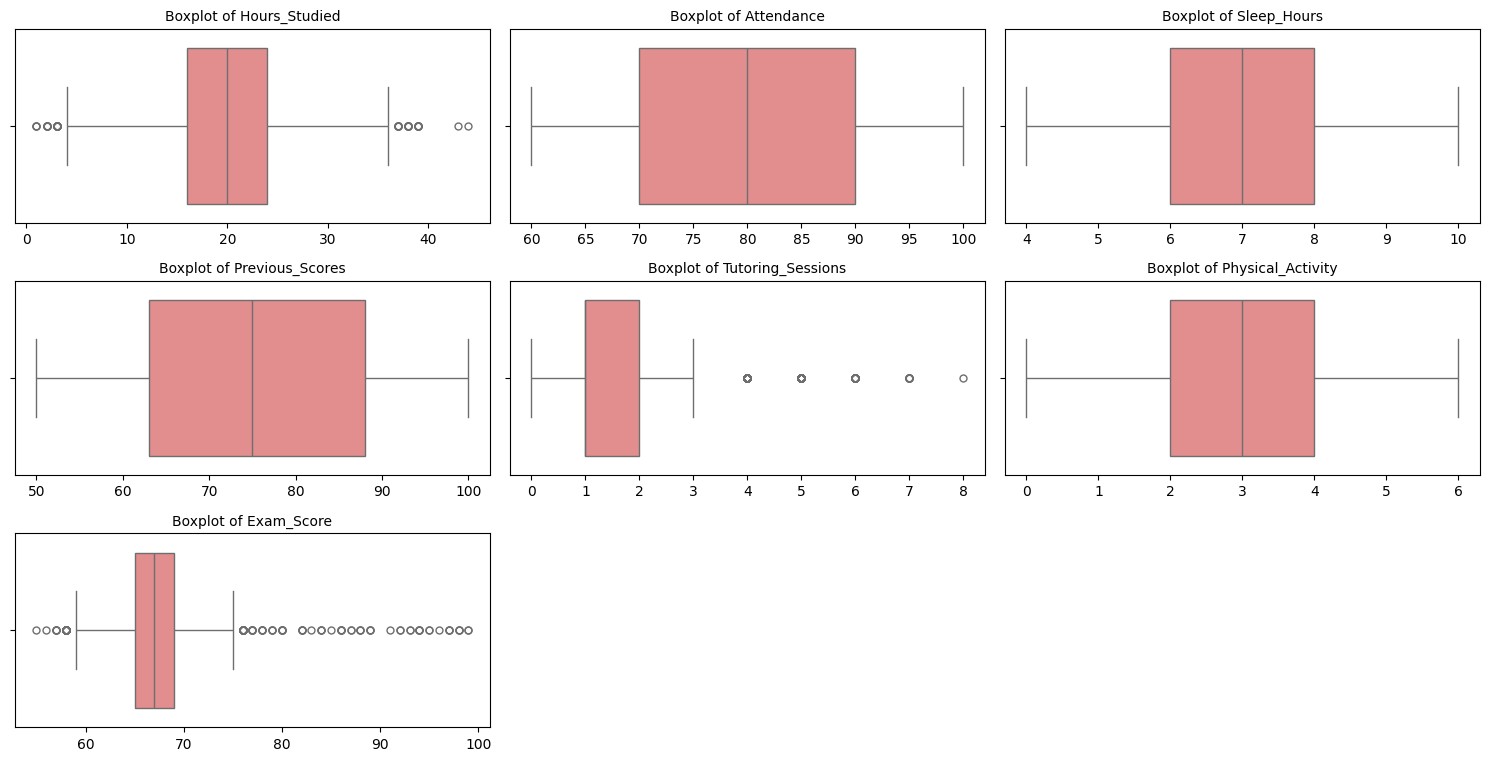

In [11]:

num_col = df.select_dtypes(include="int64").columns


fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 10))


axes = axes.flatten() 


for i, col in enumerate(num_col):
    sns.boxplot(data=df, x=col, ax=axes[i], color="lightcoral", fliersize=5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=10)
    axes[i].set_xlabel('') 


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [12]:
highest_allowed=df["Hours_Studied"].mean()+3*df["Hours_Studied"].std()
lowest_allowed=df["Hours_Studied"].mean()-3*df["Hours_Studied"].std()

df["Hours_Studied"]=np.where(df["Hours_Studied"]>highest_allowed,highest_allowed,np.where(df["Hours_Studied"]<lowest_allowed,lowest_allowed,df["Hours_Studied"]))


In [13]:
q1=df["Tutoring_Sessions"].quantile(0.25) 
q3=df["Tutoring_Sessions"].quantile(0.75)

iqr=q3-q1

highest_allowed1=q3+1.5*iqr
lowest_allowed1=q1-1.5*iqr

df["Tutoring_Sessions"]=np.where(df["Tutoring_Sessions"]>highest_allowed1,highest_allowed1,np.where(df["Tutoring_Sessions"]<lowest_allowed1,lowest_allowed1,df["Tutoring_Sessions"]))
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000
mean,19.972168,79.973354,7.029674,75.068130,1.435806,2.967752,67.225587
std,5.979963,11.546559,1.467815,14.400252,1.095720,1.031318,3.847720
min,2.002079,60.000000,4.000000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000
max,37.947050,100.000000,10.000000,100.000000,3.500000,6.000000,99.000000


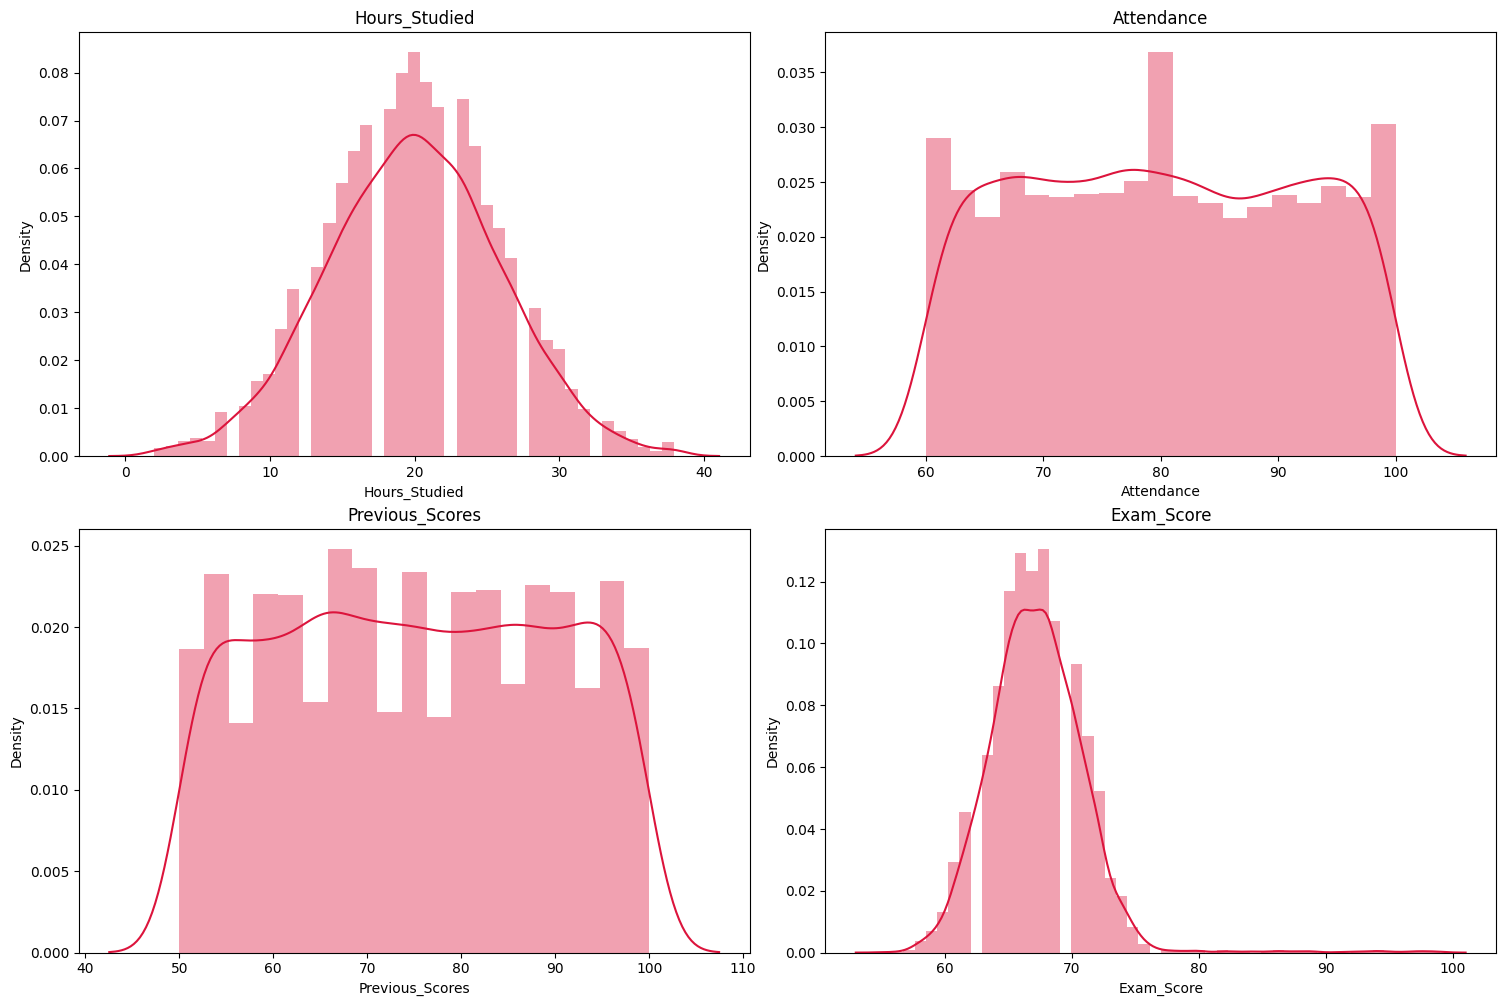

In [14]:
cor_col=df.select_dtypes(include="int64").columns

fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(15,10))
axes=axes.flatten()

for i,col in enumerate(con_col):
    sns.distplot(df[col],ax=axes[i],kde=True,color="crimson")
    axes[i].set_title(col)


plt.tight_layout(pad=0.5)

plt.show()


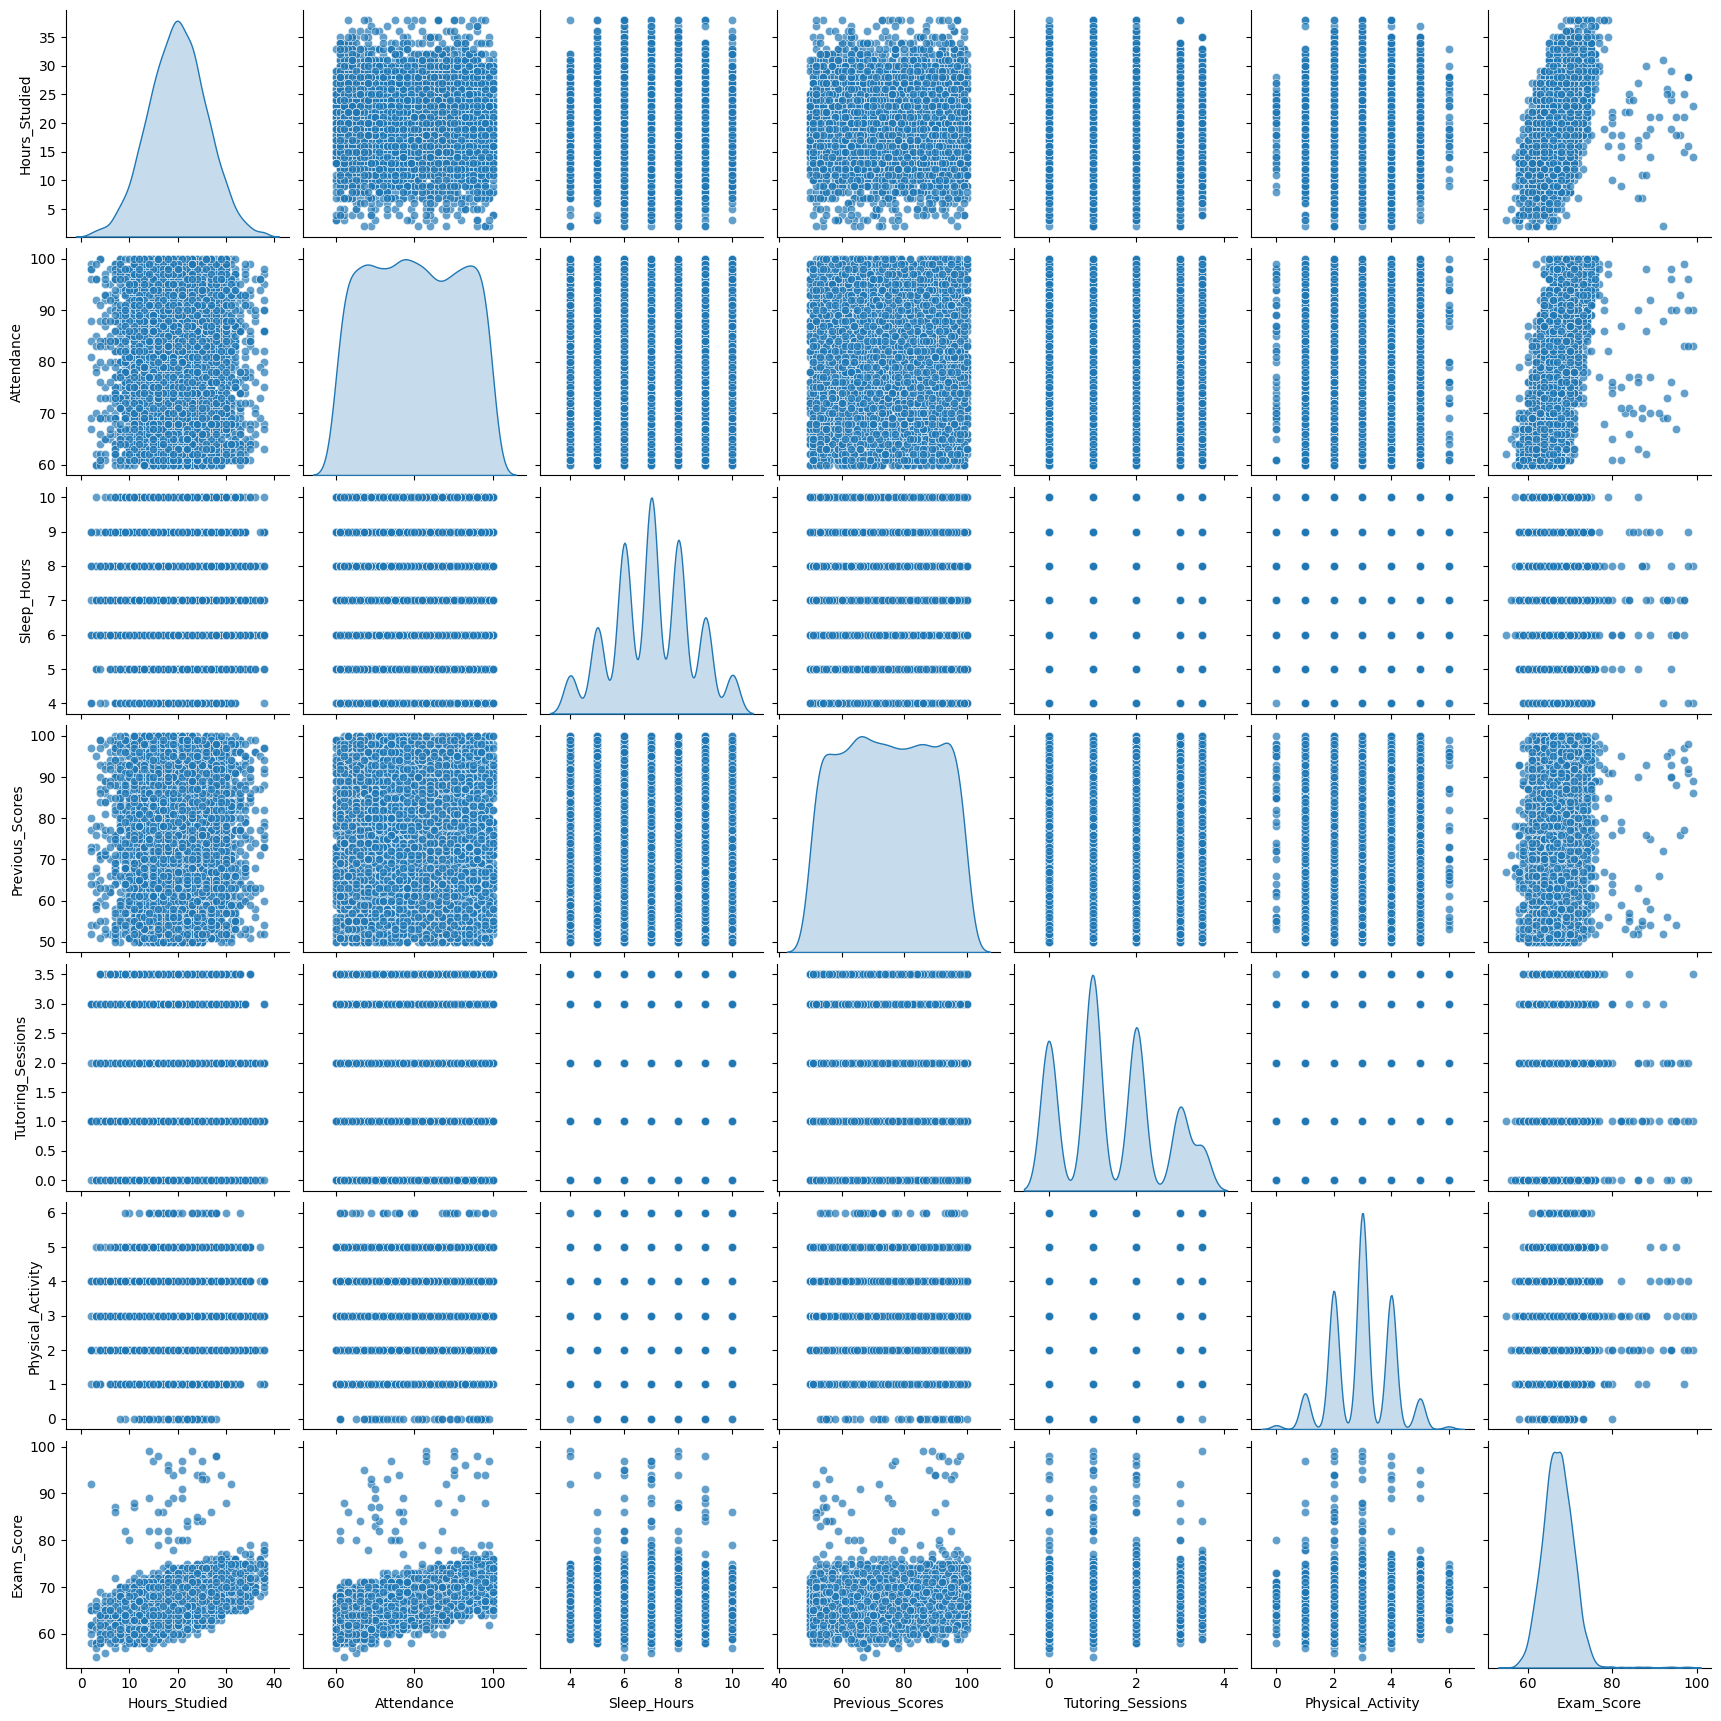

In [15]:
cor_col=df.select_dtypes(include=["int64","float64"]).columns

sns.pairplot(df[cor_col],diag_kind="kde",plot_kws={"alpha":0.7})

plt.show()

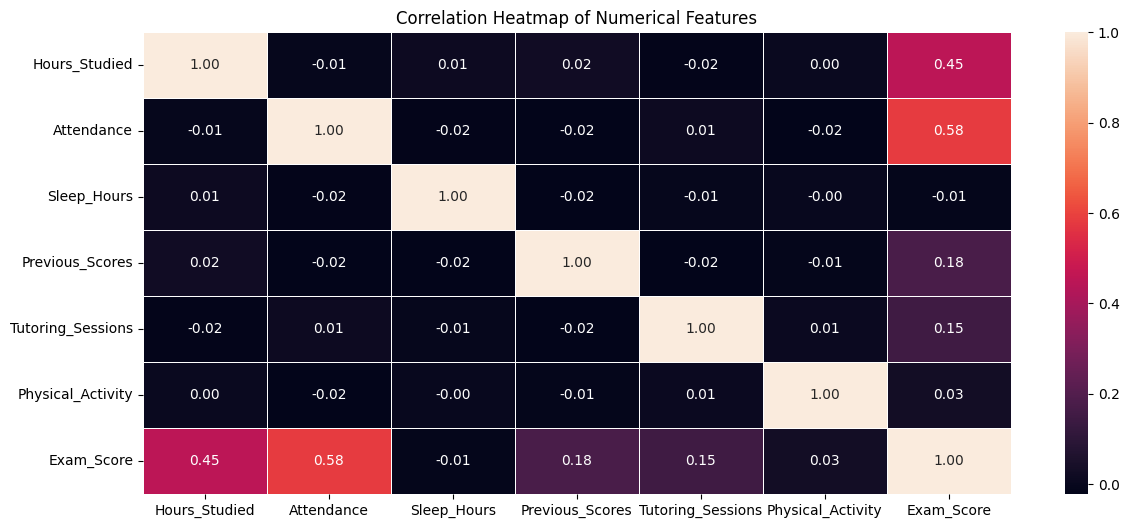

In [16]:
corr_matrix=df[cor_col].corr()

plt.figure(figsize=(14,6))

sns.heatmap(corr_matrix,annot=True,fmt=".2f",linewidths=0.5 )

plt.title('Correlation Heatmap of Numerical Features')
plt.show()


In [17]:
x=df.drop(columns="Exam_Score")
y=df.iloc[:,-1]

In [18]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)



In [19]:
categories_list=[df["Parental_Involvement"].unique(),
                 df["Access_to_Resources"].unique(),
                 df["Motivation_Level"].unique(),
                 df["Family_Income"].unique()]

In [20]:
impute_ordinal=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("ordinal",OrdinalEncoder(categories=[['Low', 'Medium', 'High'],['High School', 'College', 'Postgraduate']]))
])

impute_ohe=Pipeline(steps=[
    ("impute",SimpleImputer(strategy="most_frequent")),
    ("ohe",OneHotEncoder(sparse_output=False,handle_unknown="ignore"))
])

encode_ohe=Pipeline(steps=[
    ("ohe1",OneHotEncoder(sparse_output=False,handle_unknown="ignore"))

])

encode_ord=Pipeline(steps=[
    ("ordi",OrdinalEncoder(categories=categories_list))
])



In [21]:
preprocessor=ColumnTransformer(transformers=[
    ("both",impute_ordinal,[11,16]),
    ("impute_ohe",impute_ohe,[17]),
    ("encode",encode_ohe,[4,8,12,13,15,18]),
    ("encode1",encode_ord,[2,3,7,10]),
    ("scaler",StandardScaler(with_mean=False),[0,1,5,6,9,14])
    
],remainder="drop")


In [22]:
model_pipeline=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("transform",PowerTransformer(method="yeo-johnson")),
    ("regressor",LinearRegression())
])

In [23]:
model_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('transform', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('both', ...), ('impute_ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [24]:
y_pred=model_pipeline.predict(x_test)

In [25]:
r2_score(y_test,y_pred)

0.7047748876289093

In [26]:
mean_squared_error(y_test,y_pred)

4.257013277287306

<Axes: xlabel='Exam_Score'>

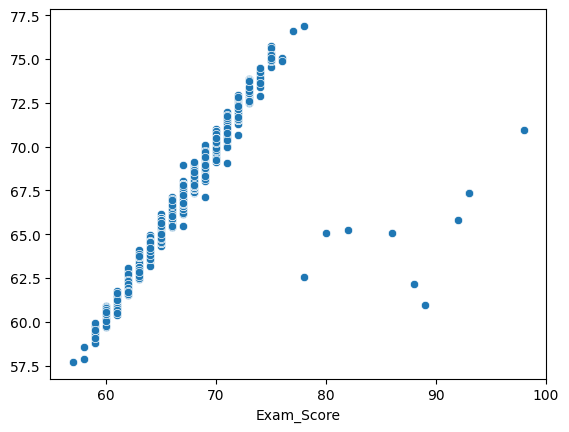

In [27]:
sns.scatterplot(x=y_test, y=y_pred)

In [28]:
# Tell the pipeline to output a pandas dataframe instead of a numpy array
model_pipeline.set_output(transform="pandas")

# Now fit and transform a sample to see it
X_transformed = model_pipeline.named_steps['preprocessor'].fit_transform(x_train)

# View the first 5 rows
X_transformed.head()

,both__Teacher_Quality,both__Parental_Education_Level,impute_ohe__Distance_from_Home_Far,impute_ohe__Distance_from_Home_Moderate,impute_ohe__Distance_from_Home_Near,encode__Extracurricular_Activities_No,encode__Extracurricular_Activities_Yes,encode__Internet_Access_No,encode__Internet_Access_Yes,encode__School_Type_Private,...,encode1__Parental_Involvement,encode1__Access_to_Resources,encode1__Motivation_Level,encode1__Family_Income,scaler__Hours_Studied,scaler__Attendance,scaler__Sleep_Hours,scaler__Previous_Scores,scaler__Tutoring_Sessions,scaler__Physical_Activity
1833,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,3.693530,6.020285,4.064974,3.678753,2.740300,1.940502
1809,2.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,2.0,2.0,1.0,2.0,4.197194,5.934281,3.387479,4.719910,1.826867,3.881004
5102,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,1.0,1.0,2.0,1.0,3.525643,6.106289,5.419966,3.748164,0.913433,2.910753
3775,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,2.0,1.0,0.0,2.0,3.861418,7.310346,5.419966,3.539933,0.000000,3.881004
6232,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,2.0,0.0,1.0,1.0,3.189867,6.450305,4.064974,6.663402,1.826867,3.881004


In [29]:
y_pred[0]

np.float64(65.2256154316269)

In [31]:
import pickle as pkl
with open("model.pkl", "wb") as file:
    pkl.dump(model_pipeline, file)